# Orders of magnitude

This short chapter is about **thinking in scales**.

You will learn how to:
- write numbers in **scientific notation**,
- compare quantities by **factors of ten** (“within an order of magnitude”),
- use **base-10 logarithms** as a *scale*,
- do quick back-of-the-envelope computations

## 1) Why orders of magnitude?

Many variables in ecological economics and sustainability science span large ranges:
- GDP per capita (thousands to tens of thousands of USD),
- population (thousands to billions),
- emissions (per person or per country) (kg to Gt).
- national energy consumption (PJ/year),
- national material use (tons/year)

If we plot or compare these values on a normal (linear) scale, the small stuff disappears.
A **logarithmic scale** fixes this by turning multiplicative gaps (×10, ×100, ×1000) into additive steps (+1, +2, +3).

### Seeing it: linear scale vs. log scale

Population is a good example — it really does span "thousands to billions" across countries. Plot a handful of countries on an ordinary axis and see what happens.

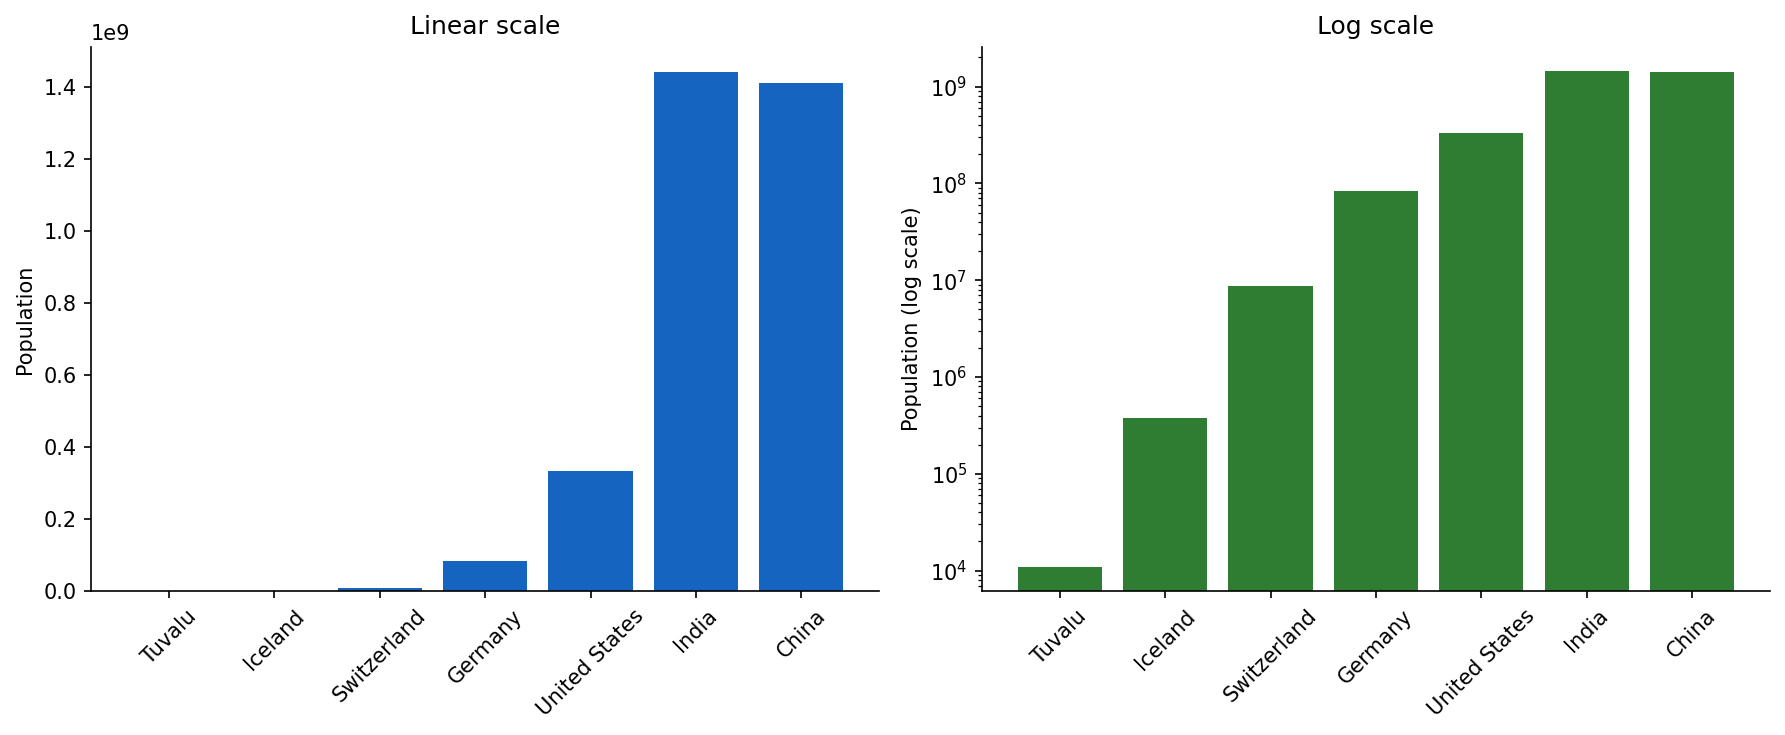

In [1]:
import matplotlib.pyplot as plt

countries = ["Tuvalu", "Iceland", "Switzerland", "Germany", "United States", "India", "China"]
population = [11_000, 380_000, 8_800_000, 84_000_000, 333_000_000, 1_440_000_000, 1_410_000_000]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

# Left: linear scale - the small countries barely register
ax1.bar(countries, population, color="#1565C0")
ax1.set_title("Linear scale")
ax1.set_ylabel("Population")
ax1.tick_params(axis="x", rotation=45)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# Right: same data, log scale - every country becomes readable
ax2.bar(countries, population, color="#2E7D32")
ax2.set_yscale("log")
ax2.set_title("Log scale")
ax2.set_ylabel("Population (log scale)")
ax2.tick_params(axis="x", rotation=45)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

On the left, Tuvalu and Iceland don't even show up — China's bar (about 1.4 billion) makes anything in the thousands invisible at that scale. On the right, same data, log axis: every country gets a bar you can actually read, and the height differences now track orders of magnitude instead of raw counts. That's the "log scale fixes it" idea from above, made visible instead of just described.

## 2) Scientific notation

Any positive number can be written as

```{math}
n = a\times 10^b,
```

where:
- the exponent **`b`** is an integer, and
- the mantissa **`a`** is a number around 1 (for example between 1 and 10).

Examples:
- 3,200 = 3.2 × 10³  
- 0.007 = 7 × 10⁻³  
- 81,000,000 = 8.1 × 10⁷

This representation makes scale comparisons easy: the exponent `b` tells you roughly “how many zeros.”


## Mini-exercise: scientific notation

Convert each of these three numbers to scientific notation $n = a \times 10^b$ with $1 \le a < 10$:

1. $n_1 = 11{,}500{,}000$
2. $n_2 = 0.00034$
3. $n_3 = 2{,}700$

Work each one out by hand, then fill in your answers as `a` and `b` for each number in the cell below.

In [2]:
# Write your answers here - replace each None with your values.

n1 = 11_500_000
a1, b1 = None, None

n2 = 0.00034
a2, b2 = None, None

n3 = 2_700
a3, b3 = None, None

Run the cell below to check your work.

In [3]:
def check(n, a, b, label):
    if a is None or b is None:
        print(f"{label}: not answered yet.")
        return
    assert 1 <= a < 10, f"{label}: mantissa {a} is not in [1, 10)"
    assert abs(a * 10**b - n) < 1e-6, f"{label}: {a} * 10**{b} does not equal {n}"
    print(f"{label}: correct - {a} x 10^{b} = {n}")

check(n1, a1, b1, "n1")
check(n2, a2, b2, "n2")
check(n3, a3, b3, "n3")

n1: not answered yet.
n2: not answered yet.
n3: not answered yet.


## 3) “Within an order of magnitude” = “within a factor of 10”

Two positive numbers `x` and `y` are **within an order of magnitude** if the larger is **less than 10 times** the smaller:

So:
- 2 and 9 are within an order of magnitude (9/2 = 4.5),
- 2 and 200 are *not* (200/2 = 100).
- 2 and 20 are also not *not* for the purpose of this book. Some conventions would say this is within one order of magnitude, but we strictly say this only if it is less than a ten times difference. 

The exact boundary convention matters less than the **habit**: asking “is this a ×2 difference, ×10, ×100?”.


## Mini-exercise: scientific notation with energy use

Suppose (roughly) that annual **energy use per person** is:

- USA: **300 GJ/person/year**
- Nigeria: **10 GJ/person/year**

1. Write each value in scientific notation  $a\times 10^b$ with  $1 \le a < 10$.  
2. Compare the two values by a **ratio**. About how many “times larger” is the USA value?  
3. Is that difference **within one order of magnitude** (a factor of 10), or not?

<details>
<summary><b>Solution (click to expand)</b></summary>

### 1) Scientific notation

- USA:  
 $300 = 3.0 \times 10^{2}$

  so \(a=3.0\), \(b=2\).

- Nigeria:  
  $10 = 1.0 \times 10^{1}$
  so \(a=1.0\), \(b=1\).

### 2) Ratio (times larger)

$\frac{300}{10} = 30$

So the USA value is about **30× larger**.

### 3) Order-of-magnitude check

A factor of 10 corresponds to **one order of magnitude**.  
Since $30 = 3\times 10$, the difference is **a bit more than one order of magnitude**  
(about $(\log_{10}(30)\approx 1.48\)$ orders of magnitude).
</details>



## 4) Logarithms


```{admonition} Logarithms for dummies (base 10)
:class: tip

A **logarithm** is just the *inverse* of exponentiation.

### What does {math}`\log_{10}(x)` mean?
It answers:

> **“Which power of 10 gives me `x`?”**

So if {math}`10^b = x`, then

```{math}
\log_{10}(x) = b.
```

### A note on the notation
- The subscript **10** in {math}`\log_{10}` tells you the **base**.  
  So {math}`\log_{10}` means “log base 10”.
- The input in parentheses, the **argument** {math}`x`, is the number you’re taking the log of.
- In many books you’ll also see:
  - {math}`\ln(x)` which means the **natural log** (base {math}`e \approx 2.718`)
  - sometimes just {math}`\log(x)` with the base left implicit (annoying, but common).
- In this chapter, we use **base 10** because it matches “orders of magnitude” (powers of ten).

Equivalently, this is the key “inverse” relationship:

```{math}
\log_{10}(10^b)=b.
```

Quick examples:
- {math}`\log_{10}(1)=0` because {math}`10^0=1`
- {math}`\log_{10}(10)=1` because {math}`10^1=10`
- {math}`\log_{10}(1000)=3` because {math}`10^3=1000`
- {math}`\log_{10}(0.01)=-2` because {math}`10^{-2}=0.01`
```

Here's what that function actually looks like — the four "quick examples" above are marked on the curve:

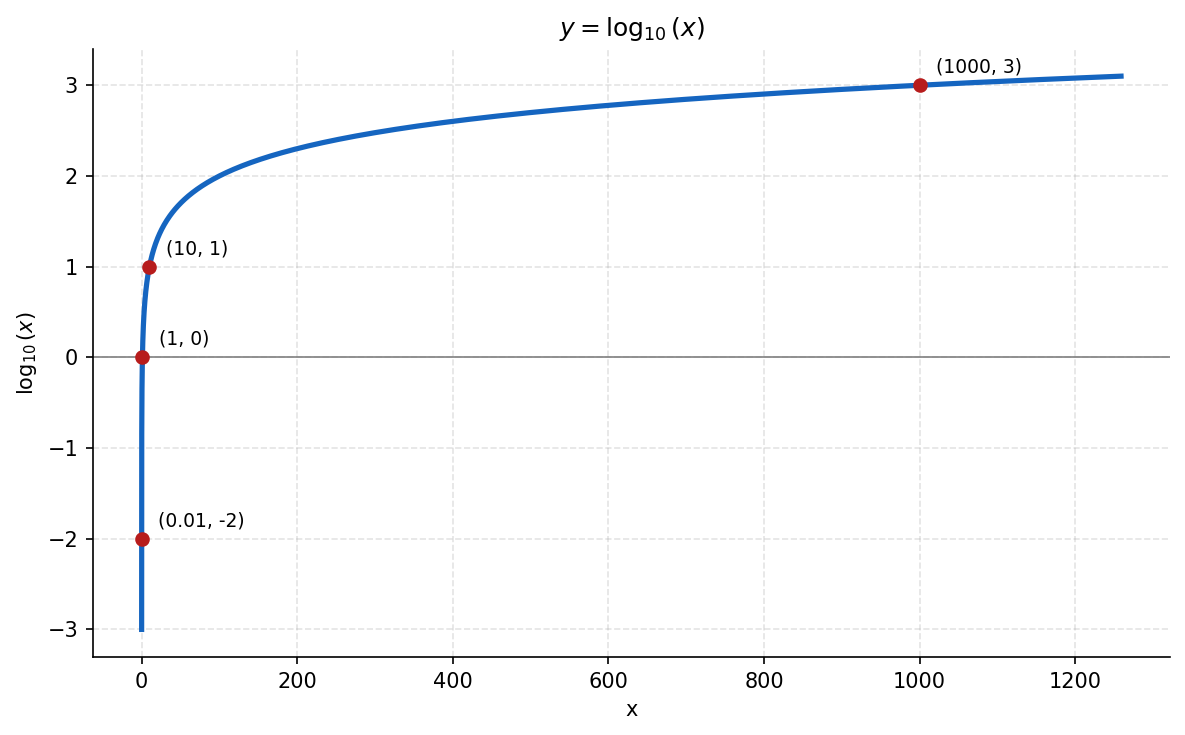

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# sample densely across scales (log-spaced points), but plot on a normal (linear) x-axis
x = np.logspace(-3, 3.1, 500)
y = np.log10(x)

fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
ax.plot(x, y, color="#1565C0", linewidth=2.5)
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_xlabel("x")
ax.set_ylabel(r"$\log_{10}(x)$")
ax.set_title(r"$y = \log_{10}(x)$")
ax.grid(True, linestyle="--", alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for xv, yv in [(0.01, -2), (1, 0), (10, 1), (1000, 3)]:
    ax.scatter([xv], [yv], color="#B71C1C", zorder=5)
    ax.annotate(f"({xv:g}, {yv})", (xv, yv), textcoords="offset points", xytext=(8, 6), fontsize=9)

plt.tight_layout()
plt.show()

## 5) Logarithms as a scale ruler

The base-10 logarithm answers:

“What power of 10 gives this number?”

```{math}
\log_{10}(10^b)=b.
```

And the key identity:

```{math}
\log_{10}(x/y)=\log_{10}(x)-\log_{10}(y).
```

So the **difference in orders of magnitude** between `x` and `y` is basically:

```{math}
\Delta \text{orders} \approx \log_{10}(x) - \log_{10}(y) = \log_{10}(x/y).
```

Example: if `x/y = 1000`, then `log10(1000) = 3` → a **3-order-of-magnitude** difference.


## 6) Mini exercise (with solution)

To remain and get more and more into coding habits. Try to write a python function that conducts the above scale ruler computation. This is not super important for our proceeding chapters but practice is never mistaken.

For this you also need to import the math package. Just do so via 

```python
import math
```


```{admonition} Hints
:class: tip

- **Logarithms need positive inputs**: before computing anything, check that `x > 0` and `y > 0`.
  If not, raise a `ValueError` with a helpful message.
- Convert inputs to numbers you can safely divide: use `x = float(x)` and `y = float(y)`.
  This also helps if someone passes strings like `"300"` or integers.
- The core computation is just: `math.log10(x / y)`.


```{dropdown} Solution (Python)
```python
import math

def orders_apart(x, y):
    """
    Return the difference in orders of magnitude between x and y:
    log10(x/y). Requires x>0 and y>0.
    """
    x = float(x)
    y = float(y)
    if x <= 0 or y <= 0:
        raise ValueError("orders_apart requires positive x and y.")
    return math.log10(x / y)

## Computational exercise: cross-order-of-magnitude matrix

Suppose you have an array of numbers:

```python
values = [12, 45_000, 3.2, 900_000, 0.08]
```

For every pair `(x, y)` in this array, work out how many orders of magnitude apart they are — $\log_{10}(x/y) = \log_{10}(x) - \log_{10}(y)$ — and lay all of those pairwise results out as a matrix.

Build a variable `M` holding the result as a `pandas.DataFrame`: a 5×5 table where `M.iloc[i, j]` equals $\log_{10}(\text{values}_i) - \log_{10}(\text{values}_j)$, with the original values as both the row and column labels.

Write your code in the cell below.

```{admonition} Hint
:class: tip

`pd.DataFrame(data, index=values, columns=values)` builds a table from a 2D array `data`, labeled with `values` on both axes. A nested list comprehension (or two `for` loops) is enough to build `data` itself.
```

In [5]:
import numpy as np
import pandas as pd

values = [12, 45_000, 3.2, 900_000, 0.08]

# Your code here.
M = None

Run the cell below to check your work.

In [6]:
def check_matrix(M, values):
    if M is None:
        print("not answered yet.")
        return
    arr = np.asarray(M, dtype=float)
    n = len(values)
    assert arr.shape == (n, n), f"expected a {n}x{n} matrix, got shape {arr.shape}"
    expected = np.array([[np.log10(x) - np.log10(y) for y in values] for x in values])
    assert np.allclose(arr, expected, atol=1e-6), "matrix values don't match log10(x) - log10(y) for each pair"
    assert np.allclose(np.diag(arr), 0, atol=1e-6), "the diagonal should be all zeros - every number is 0 orders of magnitude from itself"
    assert np.allclose(arr, -arr.T, atol=1e-6), "the matrix should be antisymmetric: M[i][j] == -M[j][i]"
    print("correct - matrix matches, diagonal is zero, and it's antisymmetric as expected.")

check_matrix(M, values)

not answered yet.


## 7) Takeaways

- An **order of magnitude** is a factor of ~10.
- Scientific notation separates **scale** (`10^b`) from **detail** (`a`).
- Logarithms turn **multiplicative** differences into **additive** differences.

In the next chapter we are going to learn about static scaling relationships in Ecological Economics and pick up some of the most important concepts in all of ecological economics (and sometimes all of science) along the way - Log–log plots, A first look at basic regression analysis and elasticities.


## 8) Extras – a little more math

So far, we used a simple rule:

> Numbers are **within one order of magnitude** if they differ by **less than a factor of 10**.

That rule is practical and easy. But there is also a more mathematical way to think about *which power of 10 a number is closest to*.

### 8.1) The key idea: the geometric mean

Suppose we want to know whether a number is closer to:

- $10^k$, or
- $10^{(k+1)}$

On a logarithmic scale, the midpoint between them is the **geometric mean**:

$sqrt(10^k * 10^{(k+1)}) = 10^{(k + 0.5)}$

Since:

$sqrt(10) ≈ 3.16$

this means:

- values up to about $3.16 × 10^k$ are closer to $10^k$
- values above that are closer to $10^{(k+1)}$

### 8.2) Example

Consider:

- $10^2 = 100$
- $10^3 = 1000$

Their geometric mean is:

$sqrt(100 × 1000) ≈ 316$

So:

- 200 is closer to 100
- 500 is closer to 1000

On a logarithmic scale, 316 is exactly halfway between 100 and 1000.

Here's that same example laid out on a number line (log scale, so the spacing itself reflects the geometric mean being the true midpoint):

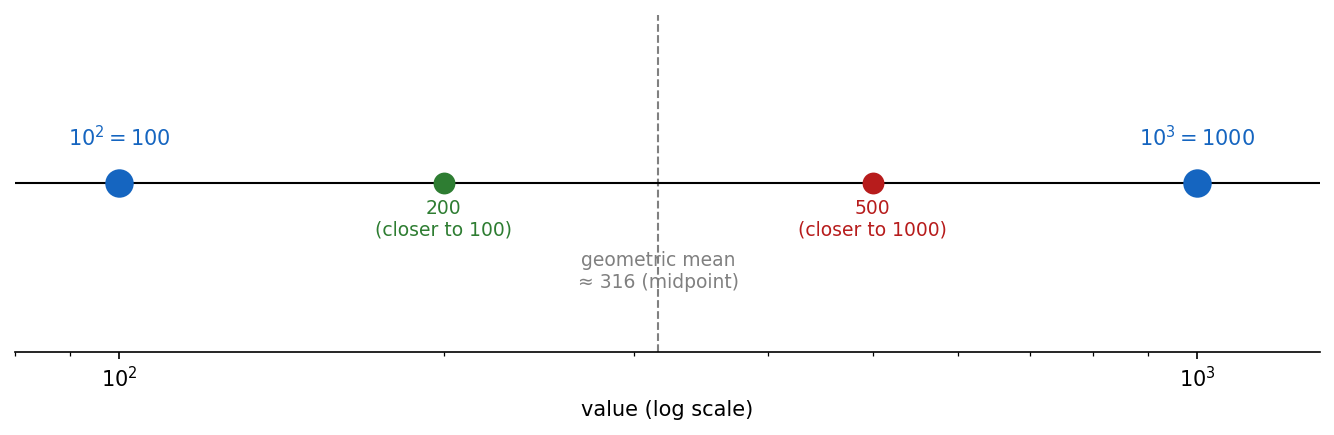

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3), dpi=150)

# the two "anchor" powers of ten
ax.scatter([100, 1000], [0, 0], s=160, color="#1565C0", zorder=5)
ax.annotate(r"$10^2 = 100$", (100, 0), textcoords="offset points", xytext=(0, 18),
            ha="center", fontsize=10, color="#1565C0")
ax.annotate(r"$10^3 = 1000$", (1000, 0), textcoords="offset points", xytext=(0, 18),
            ha="center", fontsize=10, color="#1565C0")

# the geometric mean = the true midpoint on a log scale
geo_mean = (100 * 1000) ** 0.5
ax.axvline(geo_mean, color="gray", linestyle="--", linewidth=1)
ax.annotate(f"geometric mean\n≈ {geo_mean:.0f} (midpoint)", (geo_mean, 0),
            textcoords="offset points", xytext=(0, -50), ha="center", fontsize=9, color="gray")

# the two example numbers, colored by which anchor they're actually closer to
for val, label in [(200, "closer to 100"), (500, "closer to 1000")]:
    color = "#2E7D32" if val < geo_mean else "#B71C1C"
    ax.scatter([val], [0], s=90, color=color, zorder=6)
    ax.annotate(f"{val}\n({label})", (val, 0), textcoords="offset points",
                xytext=(0, -25), ha="center", fontsize=9, color=color)

ax.set_xscale("log")
ax.set_xlim(80, 1300)
ax.set_ylim(-1, 1)
ax.set_yticks([])
ax.set_xlabel("value (log scale)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.axhline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()

### 8.3) Logarithmic interpretation

On a log scale:

- $log_10(10^k) = k$
- $log_10(10^{(k+1)}) = k + 1$

The midpoint is:

$k + 0.5$

Converting back:

$10^{(k + 0.5)}$

So the geometric mean is simply the midpoint in logarithmic space.

### 8.4) Mini example

Suppose a system uses about 500 tons per year.

Compare:

- $10^2 = 100$
- $10^3 = 1000$

Since 500 > 316, it is closer to 1000.

So we say it is roughly on the scale of:

$10^3$ tons/year.